In [ ]:
# Jack Farrell
# Reinforcement Learning
# Pset 3 Problem 2 TD(0) State-Value Implementation
# 6Jul26

# Implement TD(0) for the following episode:
# States: A,B,C,D,E,F,G
# Rewards R = +1 for transitioning to G; R = 0 for all other transitions; A and G are terminal
# Values: V(s)=0.5 for all non-terminal states, for A and G, V(s) = 0 
# Transitions: left/right with equal probability under the fixed behavior policy
# Discount: 

# AI usage: I used ChatGPT to help me debug the TD(0) and Monte Carlo functions and help interpret error messages as they arose.

import numpy as np
import matplotlib.pyplot as plt

### Event Setup

In [224]:
path =        ['A','B', 'C', 'D', 'E', 'F', 'G']
rewards =     [ 0,  0,   0,   0,   0,   0,   1]
values =      [ 0, 0.5, 0.5, 0.5, 0.5, 0.5,  0]
true_values =     [1/6, 2/6, 3/6, 4/6, 5/6]
actions = [-1, 1]   # [left, right]
episodes = 100
rms = []

### Define the TD(0) Function (Part C)

In [225]:
def td0_run(path, rewards, values, actions, alpha, gamma):

    # Initialize start location
    current_location = np.random.choice([1,2,3,4,5])

    while path[current_location] not in ['A','G']:

        # Perform action
        pick_action = np.random.choice(actions)

        # Take action and observe new state
        new_location = current_location + pick_action
        reward = rewards[new_location]

        # Perform TD Update
        values[current_location] = values[current_location] + alpha * (reward + gamma*values[new_location] - values[current_location])

        # reset index
        current_location = new_location
        
    return values

### Define Monte Carlo Function

In [226]:
def mc_run(path, rewards, values, actions, alpha, gamma):

    # Initialize start location
    current_location = np.random.choice([1,2,3,4,5])

    episode_states = []
    episode_rewards = []

    #-------------------
    # Generate Episode
    #-------------------
    while path[current_location] not in ['A','G']:

        # Add current location to the episode states
        episode_states.append(current_location)

        # Perform action
        pick_action = np.random.choice(actions)

        # Take action and observe new state
        new_location = current_location + pick_action
        reward = rewards[new_location]

        # Add the reward for this step in the episode to the reward matrix
        episode_rewards.append(reward)

        # reset index
        current_location = new_location

    # Add terminal location
    episode_states.append(current_location)

    #--------------------
    # Perform MC Update
    #--------------------
    G = 0
    visited = set()

    for t in reversed(range(len(episode_states) - 1)):

        state = episode_states[t]
        reward = episode_rewards[t]

        G = gamma * G + reward

        if state not in visited:
            visited.add(state)

            values[state] += alpha * (G - values[state])

    return values

### Calculate RMS Values

In [227]:
def compute_rms(values, true_values):

    estimated = np.array(values[1:6])
    true_vals = np.array(true_values)

    return np.sqrt(np.mean((estimated - true_vals)**2))

### Part C: Solution

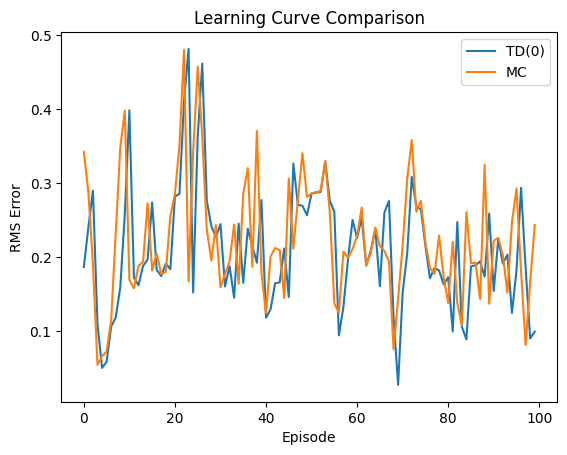

In [228]:
episodes = 100
alpha = 0.5
gamma = 1

true_values = [1/6, 2/6, 3/6, 4/6, 5/6]

rms_td0_history = []
rms_mc_history = []

for episode in range(episodes):
    # TD0 Solution
    td0_values = td0_run(path, rewards, values, actions, alpha, gamma)

    rms_td0 = compute_rms(values, true_values)
    rms_td0_history.append(rms_td0)

    # MC Solution
    mc_values = mc_run(path, rewards, values, actions, alpha, gamma)

    rms_mc = compute_rms(values, true_values)
    rms_mc_history.append(rms_mc)

plt.figure()
plt.plot(rms_td0_history, label = "TD(0)")
plt.plot(rms_mc_history, label='MC')
plt.xlabel("Episode")
plt.ylabel("RMS Error")
plt.title("Learning Curve Comparison")
plt.legend()
plt.show()


### Part D solution

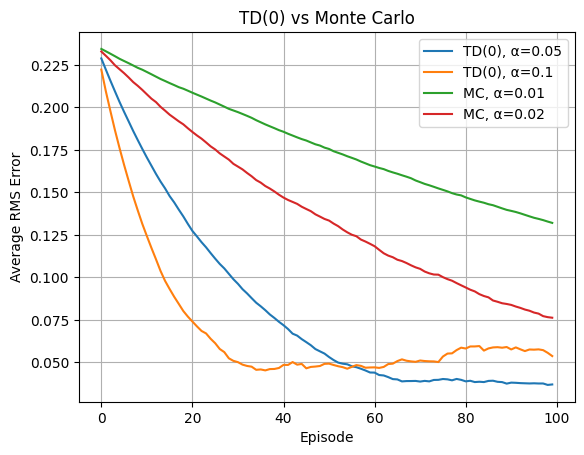

In [229]:
runs = 50
episodes = 100

# TD0 Runs
td_alphas = [0.05, 0.10]
td_results = {}

# Iterate through various alphas
for alpha in td_alphas:

    rms_sum = np.zeros(episodes)
    
    # Repeat the experiment of 100 episodes for 50 runs
    for run in range(runs):

        # Reset value function for this independent run
        values = [0, 0.5, 0.5, 0.5, 0.5, 0.5, 0]

        for episode in range(episodes):

            values = td0_run(path, rewards, values, actions, alpha, gamma)
            rms = compute_rms(values, true_values)
            rms_sum[episode] += rms     # sum total off each experiment rms

    td_results[alpha] = rms_sum / runs  # mean rms plot for 50 runs

# MC Runs
mc_alphas = [0.01, 0.02]
mc_results = {}

for alpha in mc_alphas:

    rms_sum = np.zeros(episodes)

    for run in range(runs):

        values = [0, 0.5, 0.5, 0.5, 0.5, 0.5, 0]

        for episode in range(episodes):

            values = mc_run(path, rewards, values, actions, alpha, gamma)
            rms = compute_rms(values, true_values)
            rms_sum[episode] += rms

    mc_results[alpha] = rms_sum / runs


plt.figure()

for alpha in td_alphas:
    plt.plot(td_results[alpha], label=f"TD(0), α={alpha}")

for alpha in mc_alphas:
    plt.plot(mc_results[alpha], label=f"MC, α={alpha}")

plt.xlabel("Episode")
plt.ylabel("Average RMS Error")
plt.title("TD(0) vs Monte Carlo")
plt.legend()
plt.grid(True)

plt.show()

### Part D Discussion

#### TD(0)
In the TD(0) plots, the higher α value of 0.1, learns much faster, expectedly; however, it plateaus at a higher RMS error of about 0.050 after only 25 episodes. This is due to the noise present in this larger step value. The 0.1 α can quickly learn and iterate, but as it approaches the true values, the variance present due to its larger step size will keep the RMS value oscillating and never quite approach the true answer. The smaller 0.05 α, however, approaches an RMS error of 0.035 and doesn't start plateauing until around the 80th episode. This is akin to tuning the proportional gain on a PID controller, where a larger proportional gain will scale the error signal to more closely approach the steady state signal. However, only tuning kP will result in oscillation because the is no derivative term to geometrically decay the scaled error signal from kP. The Gt term more closely resembles I control where the sum of previous rewards are scaled by kI to change the accumulated error over time. This doesn't serve as a perfect one-to-one analogy as the gamma term does not linearly scale Gt as kI would in a PI controller, but the existence of gamma is meant to diminish the effect of future, far off returns.

The MC plots exhibit similar expected behaviors as far as their learning rates are concerned. In this case, however, the time horizon for the number of episodes performed is not far enough for the smaller 0.01 α to overtake the 0.02 α. The overall slower learning rate compared to TD(0) is as a result of MC only updating the values at the end of an episode. TD(0)'s bootstrapping allows it to much more quickly approach it's steady-state than MC simply because of how often both are beign updated.